# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Students:** *Hernández González Andrés Sebastián / Luna Reyes Javier*  
**Date:** *2 de Marzo de 2026*

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [ ]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [ ]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    """
    Compute DFS coefficients X[k] for a single-period signal x[n].

    Parameters
    ----------
    x : np.ndarray, shape (N,)
        One period of the signal (n=0..N-1). Can be real or complex.

    Returns
    -------
    X : np.ndarray, shape (N,), dtype=complex
        DFS coefficients.
    """
    N = len(x)
    n = np.arange(N) #De 0 a N-1
    X = np.zeros(N, dtype=complex) #Llenar con ceros los coeficientes
    for k in range(N): #Recorriendo desde 0 a N-1
        #Almacenando el coeficiente calculado
        # (1/N)*np.sum(x * np.exp( (-1j*(2*np.pi)*k*n)/N) )
        b =  (np.exp( (-1j*(2*np.pi)*k*n)/N) )
        X[k] = (1/N) * np.dot(x, b) #suma de productos
    return X


# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    """
    Reconstruct x_hat[n] from DFS coefficients X[k].

    Parameters
    ----------
    X : np.ndarray, shape (N,), dtype=complex
        DFS coefficients.

    Returns
    -------
    x_hat : np.ndarray, shape (N,), dtype=complex
        Reconstructed one-period signal.
    """
    N = len(X)
    k = np.arange(N) #De 0 a N-1
    x_hat = np.zeros(N, dtype=complex) #Llenar con ceros los componentes
    for n in range(N):
        # np.sum(X * np.exp( (1j*(2*np.pi)*k*n)/N) )
        b = ( np.exp( (1j*(2*np.pi)*k*n)/N) )
        x_hat[n] = np.dot(X, b)
    return x_hat


def rmse(x, x_hat):
    """Root-mean-square error over one period."""
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))


In [ ]:
# === TODO 3: Build the three signals (one period only) ===

# Signal A: square wave, N1=32
N1 = 16
n1 = np.arange(N1)

# TODO: define xA as described in the instructions
xA = np.array([1.0 if val<(N1/2) else -1.0 for val in n1])

# Signal B: triangle wave, N2=48
N2 = 32
n2 = np.arange(N2)

# TODO: define xB as described in the instructions
xB = 1 - np.abs(n2 - N2/2) / (N2/2)

# Signal C: sum of sinusoids, N3=64
N3 = 64
n3 = np.arange(N3)

# TODO: define xC as described in the instructions
xC = 0.8*np.cos(2*np.pi*(1/N3)*n3)+0.4*np.sin(2*np.pi*(2/N3)*n3+0.3)+0.2*np.cos(2*np.pi*(3/N3)*n3-0.8)


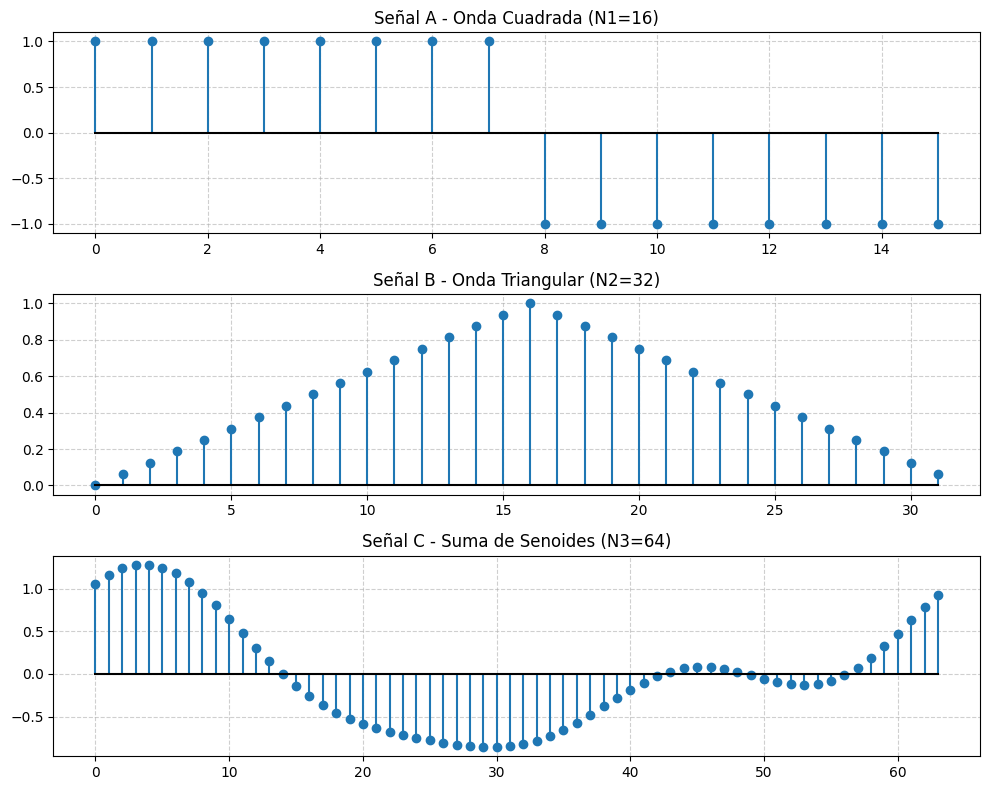

In [ ]:
# === Gráficas ===

# Crear una figura grande para que quepan las 3
plt.figure(figsize=(10, 8))

# Gráfica de la Señal A
plt.subplot(3, 1, 1)
plt.stem(n1, xA, basefmt="black")
plt.title(f"Señal A - Onda Cuadrada (N1={N1})")
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de la Señal B
plt.subplot(3, 1, 2)
plt.stem(n2, xB, basefmt="black")
plt.title(f"Señal B - Onda Triangular (N2={N2})")
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de la Señal C
plt.subplot(3, 1, 3)
plt.stem(n3, xC, basefmt="black")
plt.title(f"Señal C - Suma de Senoides (N3={N3})")
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar los espacios para que no se encimen los títulos
plt.tight_layout()
plt.show()

## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square): N=16, RMSE=3.027273e-15


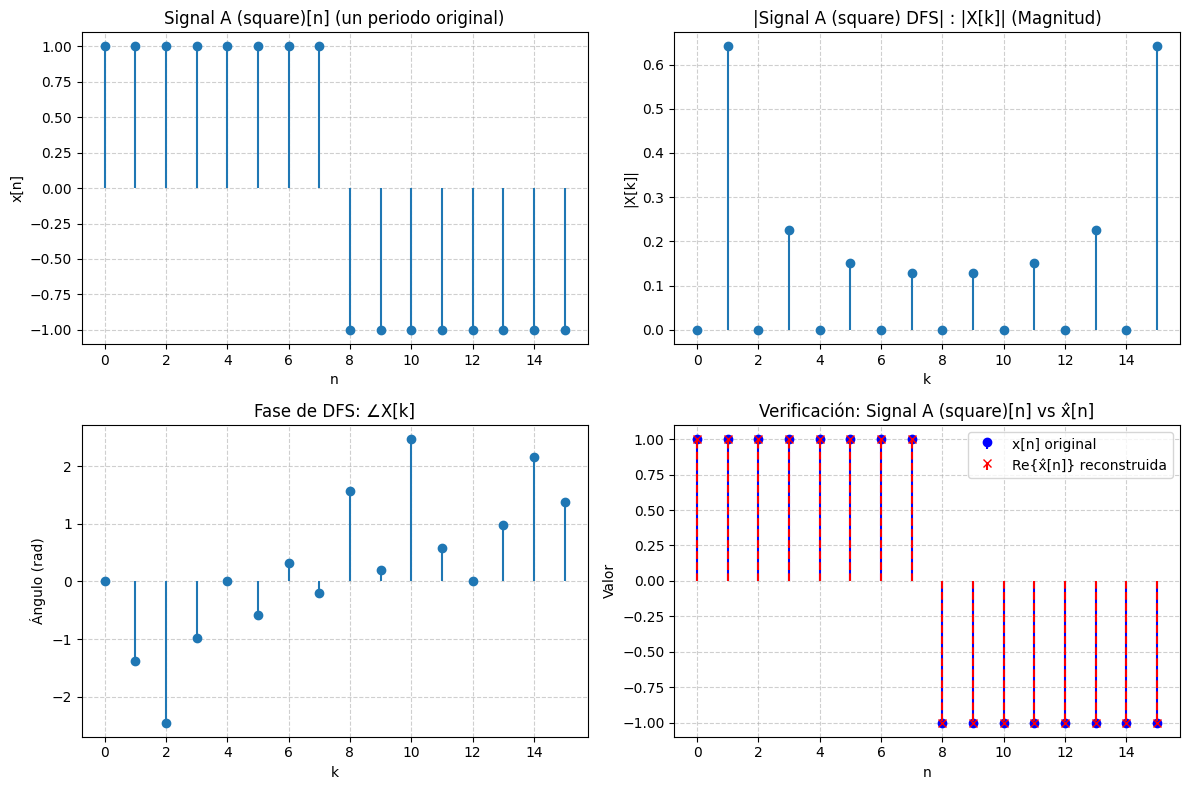

Signal B (triangle): N=32, RMSE=1.846558e-15


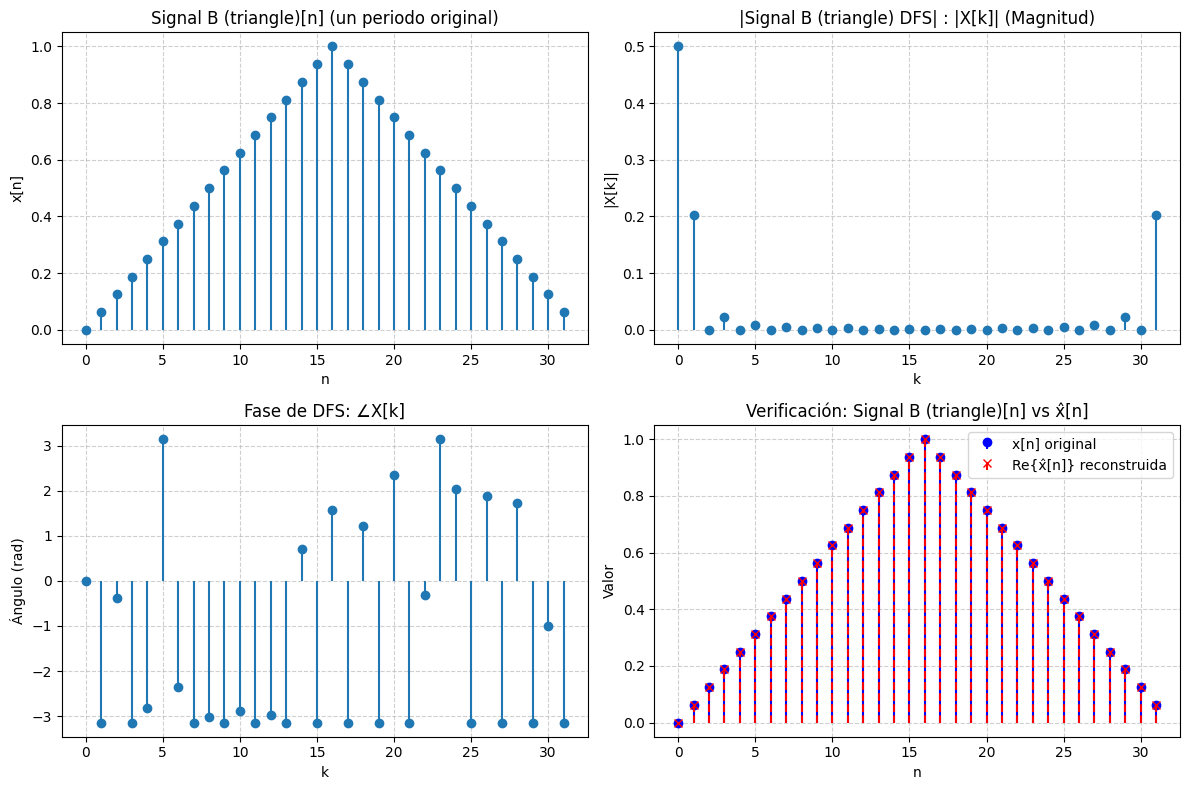

Signal C (sum of sinusoids): N=64, RMSE=7.332764e-15


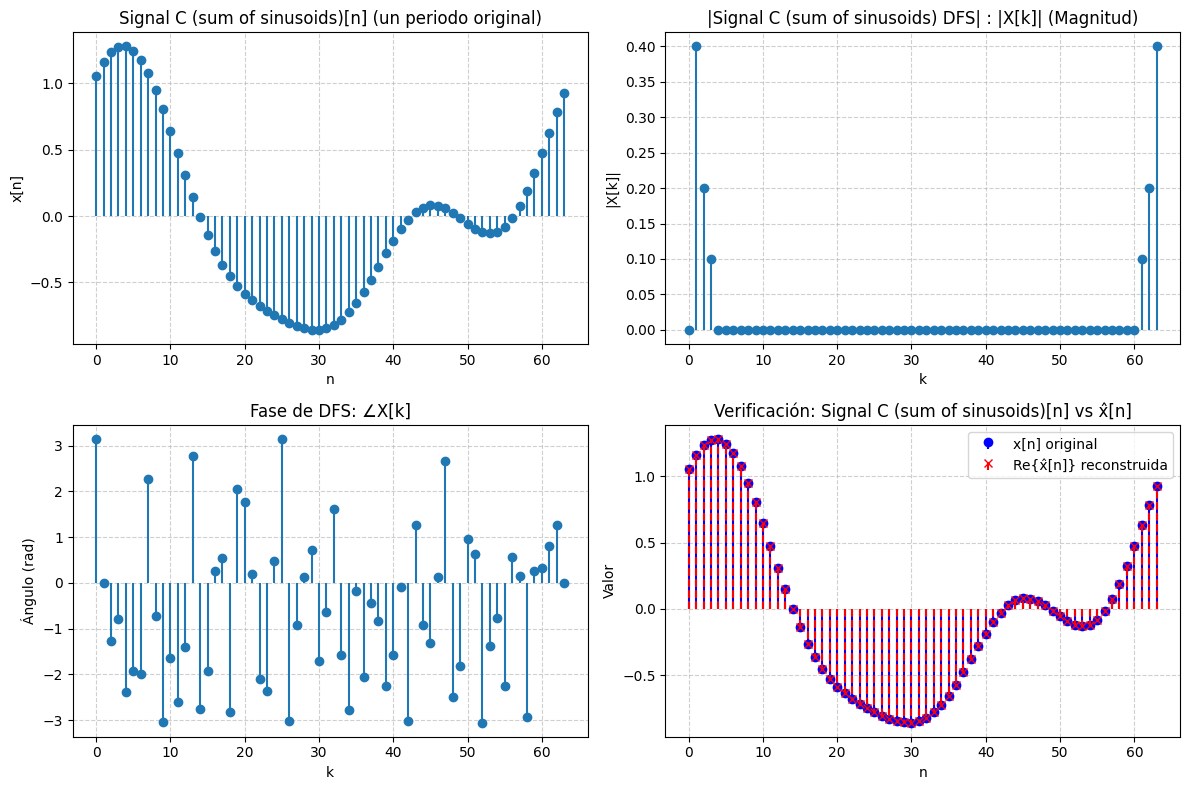

In [ ]:
def analyze_signal(x, name="x"):
    """Compute DFS, reconstruct, plot, and print RMSE for one period."""
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    # Asumimos que la función rmse() ya la tienes definida en otra parte de tu código
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # === CREACIÓN DE LA FIGURA AGRUPADA ===
    # Creamos un lienzo grande (12 de ancho por 8 de alto)
    plt.figure(figsize=(12, 8))

    # --- 1. Plots: time domain (Fila 1, Columna 1) ---
    plt.subplot(2, 2, 1)
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (un periodo original)")
    plt.xlabel("n"); plt.ylabel("x[n]")
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- 2. Plots: magnitude spectrum (Fila 1, Columna 2) ---
    k = np.arange(N)
    plt.subplot(2, 2, 2)
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|{name} DFS| : |X[k]| (Magnitud)")
    plt.xlabel("k"); plt.ylabel("|X[k]|")
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- 3. Plots: phase spectrum (Fila 2, Columna 1) ---
    plt.subplot(2, 2, 3)
    plt.stem(k, np.angle(X), basefmt=" ")
    plt.title(f"Fase de DFS: ∠X[k]")
    plt.xlabel("k"); plt.ylabel("Ángulo (rad)")
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- 4. Plots: reconstruction (Fila 2, Columna 2) ---
    plt.subplot(2, 2, 4)
    plt.stem(n, np.real(x), basefmt=" ", markerfmt="bo", linefmt="b-", label="x[n] original")
    plt.stem(n, np.real(x_hat), basefmt=" ", markerfmt="rx", linefmt="r--", label="Re{x̂[n]} reconstruida")
    plt.title(f"Verificación: {name}[n] vs x̂[n]")
    plt.xlabel("n"); plt.ylabel("Valor")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return X, x_hat


# === TODO 4: Run analysis for A, B, C ===
# Uncomment when you have implemented dfs/idfs and signals.

XA, xA_hat = analyze_signal(xA, name="Signal A (square)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")


## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

*(Write 2–4 sentences per signal.)*


SEÑAL CUADRADA

Para esta señal dos coeficientes son dominantes en magnitud (1 y 15).
Por otra parte, la fase en esta señal, no parece ruidosa; sin embargo, algo que se puede destacar
Al mantener solo los coeficientes con mayor



SEÑAL TRAINGULAR


SEÑAL SUMA DE SINUSOIDALES